# **CP462 Project:  NVIDIA Stock Price Analysis**

# หัวข้อ : **NVIDIA Stock Price Analysis**

**สมาชิก:**
<br>1) นายรพีภัทร อุ่นคำ เลขนิสิต 	66102010152
<br>2) นายธนพธ์ อุ่นทรัพย์ 		   	66102010239
<br>3) นายภคพล ต้นสาลี	       66102010243
<br><br>

**Dataset:** NVIDIA Corporation (NVDA) Stock | 2015 - 2024 <br>
**Source:** https://www.kaggle.com/code/fareedalianwar/nvidia-corporation-nvda-stock-2015-2024/notebook


**Dataset:** Forex Factory Economic Data Entire Dataset <br>
**Source:** https://www.kaggle.com/datasets/randelltsen/forex-factory-entire-dataset-till-2024-08-16

# Data Wrangling


## Task 1: Gathering

In [ ]:
import pandas as pd
df_stock = pd.read_csv('nvidia_stock_2015_to_2024.csv')
df_stock.head()

,Unnamed: 0,date,open,high,low,close,adjclose,volume
0,0,2015-01-02,0.50325,0.50700,0.49525,0.50325,0.483218,113680000
1,1,2015-01-05,0.50325,0.50475,0.49250,0.49475,0.475056,197952000
2,2,2015-01-06,0.49550,0.49600,0.47925,0.47975,0.460654,197764000
3,3,2015-01-07,0.48325,0.48750,0.47700,0.47850,0.459453,321808000
4,4,2015-01-08,0.48400,0.49950,0.48375,0.49650,0.476737,283780000


In [ ]:
df_news = pd.read_csv('scrape.csv')
df_news.head()

,id,datetime,currency,event,impact,actual,actual_unit,forecast,forecast_unit,previous,previous_unit,previous_revised
0,12245,2007-01-01 00:00:00,CAD,Bank Holiday,Non-Economic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12036,2007-01-01 00:00:00,CHF,Bank Holiday,Non-Economic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23272,2007-01-01 00:00:00,CNY,Bank Holiday,Non-Economic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,12214,2007-01-01 00:00:00,EUR,French Bank Holiday,Non-Economic,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,12186,2007-01-01 00:00:00,EUR,German Bank Holiday,Non-Economic,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Task 2: Cleaning

In [ ]:
if "Unnamed: 0" in df_stock.columns:
    df_stock = df_stock.drop(columns=["Unnamed: 0"])

In [ ]:
# missing values
print("จำนวน missing values:")
print(df_stock.isnull().sum())

# duplicates
print("\nจำนวน duplicates:")
print(df_stock.duplicated().sum())

จำนวน missing values:
date        0
open        0
high        0
low         0
close       0
adjclose    0
volume      0
dtype: int64

จำนวน duplicates:
0


In [ ]:
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข
numeric_cols = df_stock.select_dtypes(include=["float64", "int64"]).columns

# ตรวจสอบว่ามีค่า < 0 หรือไม่
for col in numeric_cols:
    number_neg = (df_stock[col] < 0).sum()
    if number_neg > 0:
        print(f"คอลัมน์ {col} พบค่าติดลบ {number_neg} ค่า")
    else:
        print(f"คอลัมน์ {col} ไม่มีค่าติดลบ")

คอลัมน์ open ไม่มีค่าติดลบ
คอลัมน์ high ไม่มีค่าติดลบ
คอลัมน์ low ไม่มีค่าติดลบ
คอลัมน์ close ไม่มีค่าติดลบ
คอลัมน์ adjclose ไม่มีค่าติดลบ
คอลัมน์ volume ไม่มีค่าติดลบ


In [ ]:
cols = ["open","high","low","close","adjclose"]

outlier_counts = {}

for c in cols:
    q1 = df_stock[c].quantile(0.25)
    q3 = df_stock[c].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr

    # นับจำนวน outlier
    IQR_cnt = int(((df_stock[c] < low) | (df_stock[c] > high)).sum())
    outlier_counts[c] = IQR_cnt

    print(f"{c}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}, low={low:.2f}, high={high:.2f}")
print("\nOutliers per column:", outlier_counts)

open: Q1=3.00, Q3=17.92, IQR=14.92, low=-19.38, high=40.29
high: Q1=3.05, Q3=18.24, IQR=15.20, low=-19.75, high=41.04
low: Q1=2.95, Q3=17.63, IQR=14.69, low=-19.08, high=39.66
close: Q1=3.03, Q3=17.98, IQR=14.95, low=-19.40, high=40.41
adjclose: Q1=2.99, Q3=17.96, IQR=14.97, low=-19.47, high=40.42

Outliers per column: {'open': 244, 'high': 244, 'low': 244, 'close': 243, 'adjclose': 243}


In [ ]:
if "actual_unit" in df_news.columns:
    df_news = df_news.drop(columns=["actual_unit"])
if "forecast_unit" in df_news.columns:
    df_news = df_news.drop(columns=["forecast_unit"])
if "previous_unit" in df_news.columns:
    df_news = df_news.drop(columns=["previous_unit"])
if "previous_revised" in df_news.columns:
    df_news = df_news.drop(columns=["previous_revised"])
if "id" in df_news.columns:
    df_news = df_news.drop(columns=["id"])

In [ ]:
df_news["datetime"] = pd.to_datetime(df_news["datetime"], errors="coerce")
df_news = df_news.sort_values(by='datetime')

is_usd   = df_news["currency"].fillna("").str.upper().eq("USD")
is_high  = df_news["impact"].fillna("").str.strip().eq("High Impact Expected")
in_years = df_news["datetime"].dt.year.between(2015, 2024)

# ชื่อเหตุการณ์ที่ต้องการ
keywords = [
    "Federal Funds Rate",
    "CPI",
]
pattern = "|".join(keywords)
has_event = df_news["event"].fillna("").str.contains(pattern, case=False, na=False)

df_news = (
    df_news.loc[is_usd & is_high & in_years & has_event]
              .sort_values("datetime")
              .reset_index(drop=True)
)

## Task 3: Transforming

In [ ]:
# date -> datetime (ค่าที่แปลงไม่ได้เป็น NaT แล้วทิ้ง)
df_stock["date"] = pd.to_datetime(df_stock["date"], errors="coerce")
df_stock = df_stock.sort_values(by='date')

In [ ]:
df_stock.head()

,date,open,high,low,close,adjclose,volume
0,2015-01-02,0.50325,0.50700,0.49525,0.50325,0.483218,113680000
1,2015-01-05,0.50325,0.50475,0.49250,0.49475,0.475056,197952000
2,2015-01-06,0.49550,0.49600,0.47925,0.47975,0.460654,197764000
3,2015-01-07,0.48325,0.48750,0.47700,0.47850,0.459453,321808000
4,2015-01-08,0.48400,0.49950,0.48375,0.49650,0.476737,283780000


In [ ]:
# หุ้น
df_stock["date"] = pd.to_datetime(df_stock["date"]).dt.normalize()

# ข่าว
df_news["datetime"] = pd.to_datetime(df_news["datetime"], errors="coerce")
df_news["date"] = df_news["datetime"].dt.normalize()                 # แปลงเป็นรายวัน

## Task 4: Enriching

In [ ]:
df_stock['MA50'] = df_stock['adjclose'].rolling(window=50).mean()
df_stock['MA200'] = df_stock['adjclose'].rolling(window=200).mean()

# ผลตอบแทนรายวัน (simple return)
df_stock["Daily_Return"] = df_stock["adjclose"].pct_change() * 100

In [ ]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2369 non-null   datetime64[ns]
 1   open          2369 non-null   float64       
 2   high          2369 non-null   float64       
 3   low           2369 non-null   float64       
 4   close         2369 non-null   float64       
 5   adjclose      2369 non-null   float64       
 6   volume        2369 non-null   int64         
 7   MA50          2320 non-null   float64       
 8   MA200         2170 non-null   float64       
 9   Daily_Return  2368 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 185.2 KB


In [ ]:
# เลือกคอลัมน์ที่อยากเก็บและรวมข้อความ/ค่าแบบง่าย ๆ
agg_news = (df_news
            .groupby("date", as_index=False)
            .agg({
                "event": lambda s: "; ".join(s.dropna().unique())[:500],  # ตัดให้สั้นหน่อย
                "impact": "first",
                "actual": "first",
                "forecast": "first",
                "previous": "first"
            }))

In [ ]:
df_merged = pd.merge(df_stock, agg_news, on="date", how="left")

In [ ]:
df_merged.tail(20)

,date,open,high,low,close,adjclose,volume,MA50,MA200,Daily_Return,event,impact,actual,forecast,previous
2349,2024-05-03,87.789001,89.280998,87.040001,88.789001,88.781708,398341000,86.499748,58.872052,3.463183,NaN,NaN,NaN,NaN,NaN
2350,2024-05-06,89.389999,92.220001,89.055000,92.139999,92.132431,376203000,86.766260,59.105183,3.774114,NaN,NaN,NaN,NaN,NaN
2351,2024-05-07,91.098000,91.780998,89.011002,90.554001,90.546562,437342000,86.995556,59.336437,-1.721293,NaN,NaN,NaN,NaN,NaN
2352,2024-05-08,89.483002,91.194000,89.419998,90.412003,90.404579,325721000,87.229830,59.565466,-0.156807,NaN,NaN,NaN,NaN,NaN
2353,2024-05-09,90.528999,91.071999,88.231003,88.747002,88.739716,378013000,87.451565,59.780838,-1.841570,NaN,NaN,NaN,NaN,NaN
2354,2024-05-10,90.305000,91.401001,89.226997,89.877998,89.870613,335325000,87.666942,60.002999,1.274398,NaN,NaN,NaN,NaN,NaN
2355,2024-05-13,90.477997,90.998001,88.528999,90.399002,90.391579,289680000,87.829406,60.225526,0.579684,NaN,NaN,NaN,NaN,NaN
2356,2024-05-14,89.598999,91.651001,88.933998,91.356003,91.348495,296507000,87.951855,60.448588,1.058635,NaN,NaN,NaN,NaN,NaN
2357,2024-05-15,92.472000,94.862000,91.598999,94.629997,94.622223,417735000,88.125161,60.688125,3.583778,Core CPI m/m; CPI y/y; CPI m/m,High Impact Expected,0.3,0.3,0.4
2358,2024-05-16,94.910004,95.819000,94.102997,94.359001,94.351250,323952000,88.238332,60.927415,-0.286374,NaN,NaN,NaN,NaN,NaN


In [ ]:
# df_stock ต้องมีคอลัมน์วันที่ชื่อ 'date' หรือ 'datetime'
date_col = 'date' if 'date' in df_merged.columns else 'datetime'
df_merged[date_col] = pd.to_datetime(df_merged[date_col])

# วันในสัปดาห์: จันทร์=0, ... อาทิตย์=6
df_merged['Day_label']   = df_merged[date_col].dt.dayofweek

# เดือน (1–12) และวันที่ (1–31)
df_merged['month'] = df_merged[date_col].dt.month
df_merged['Day']   = df_merged[date_col].dt.day

# (ทางเลือก) ฟอร์แมตเป็นสตริง "dow month day"
df_merged['Day_label_month_Day'] = (
    df_merged['Day_label'].astype(str) + ' ' +
    df_merged['month'].astype(str) + ' ' +
    df_merged['Day'].astype(str)
)

# (ทางเลือก) ถ้าไม่ต้องการใช้ปี เอาออกจากตาราง Helper นี้ได้เลย
# หรือจะลบทิ้งคอลัมน์ year ถ้ามีอยู่
if 'year' in df_merged.columns:
    df_merged = df_merged.drop(columns=['year'])

# ดูผลตัวอย่าง
print(df_merged[[date_col, 'Day_label', 'month', 'Day', 'Day_label_month_Day']].head())

        date  Day_label  month  Day Day_label_month_Day
0 2015-01-02          4      1    2               4 1 2
1 2015-01-05          0      1    5               0 1 5
2 2015-01-06          1      1    6               1 1 6
3 2015-01-07          2      1    7               2 1 7
4 2015-01-08          3      1    8               3 1 8


## Task 5: Validation

Validating : ตรวจว่า low ≤ open/close ≤ high และ low ≤ high

In [ ]:
#Validating
consistency_violation_rows = (
    (df_stock["low"] <= df_stock["open"]) &
    (df_stock["low"] <= df_stock["close"]) &
    (df_stock["open"] <= df_stock["high"]) &
    (df_stock["close"] <= df_stock["high"]) &
    (df_stock["low"] <= df_stock["high"])
).sum()

print("consistency_violation_rows:", consistency_violation_rows)

consistency_violation_rows: 2369


In [ ]:
df_stock.head(10)

,date,open,high,low,close,adjclose,volume,MA50,MA200,Daily_Return
0,2015-01-02,0.50325,0.50700,0.49525,0.50325,0.483218,113680000,NaN,NaN,NaN
1,2015-01-05,0.50325,0.50475,0.49250,0.49475,0.475056,197952000,NaN,NaN,-1.689029
2,2015-01-06,0.49550,0.49600,0.47925,0.47975,0.460654,197764000,NaN,NaN,-3.031828
3,2015-01-07,0.48325,0.48750,0.47700,0.47850,0.459453,321808000,NaN,NaN,-0.260569
4,2015-01-08,0.48400,0.49950,0.48375,0.49650,0.476737,283780000,NaN,NaN,3.761773
5,2015-01-09,0.49825,0.50225,0.49150,0.49850,0.478657,209540000,NaN,NaN,0.402797
6,2015-01-12,0.49975,0.50000,0.48775,0.49225,0.472656,190732000,NaN,NaN,-1.253740
7,2015-01-13,0.49600,0.50600,0.48800,0.49150,0.471936,236720000,NaN,NaN,-0.152361
8,2015-01-14,0.48625,0.49500,0.48500,0.49350,0.473856,155260000,NaN,NaN,0.406914
9,2015-01-15,0.49700,0.50000,0.48975,0.49000,0.470496,188932000,NaN,NaN,-0.709221


In [ ]:
print(f"จำนวนแถวที่ได้: {len(df_news):,}")
df_news.head(20)

จำนวนแถวที่ได้: 415


,datetime,currency,event,impact,actual,forecast,previous,date
0,2015-01-16 13:30:00,USD,CPI y/y,High Impact Expected,0.80,0.70,1.30,2015-01-16
1,2015-01-16 13:30:00,USD,Core CPI m/m,High Impact Expected,0.00,0.10,0.10,2015-01-16
2,2015-01-16 13:30:00,USD,CPI m/m,High Impact Expected,-0.40,-0.30,-0.30,2015-01-16
3,2015-01-28 19:00:00,USD,Federal Funds Rate,High Impact Expected,0.25,0.25,0.25,2015-01-28
4,2015-02-26 13:30:00,USD,Core CPI m/m,High Impact Expected,0.20,0.10,0.00,2015-02-26
5,2015-02-26 13:30:00,USD,CPI m/m,High Impact Expected,-0.70,-0.60,-0.40,2015-02-26
6,2015-02-26 13:30:00,USD,CPI y/y,High Impact Expected,-0.10,-0.10,0.80,2015-02-26
7,2015-03-18 18:00:00,USD,Federal Funds Rate,High Impact Expected,0.25,0.25,0.25,2015-03-18
8,2015-03-24 12:30:00,USD,CPI m/m,High Impact Expected,0.20,0.20,-0.70,2015-03-24
9,2015-03-24 12:30:00,USD,CPI y/y,High Impact Expected,0.00,-0.10,-0.10,2015-03-24


In [ ]:
df_merged.head(20)

,date,open,high,low,close,adjclose,volume,MA50,MA200,Daily_Return,event,impact,actual,forecast,previous,Day_label,month,Day,Day_label_month_Day
0,2015-01-02,0.50325,0.50700,0.49525,0.50325,0.483218,113680000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,2,4 1 2
1,2015-01-05,0.50325,0.50475,0.49250,0.49475,0.475056,197952000,NaN,NaN,-1.689029,NaN,NaN,NaN,NaN,NaN,0,1,5,0 1 5
2,2015-01-06,0.49550,0.49600,0.47925,0.47975,0.460654,197764000,NaN,NaN,-3.031828,NaN,NaN,NaN,NaN,NaN,1,1,6,1 1 6
3,2015-01-07,0.48325,0.48750,0.47700,0.47850,0.459453,321808000,NaN,NaN,-0.260569,NaN,NaN,NaN,NaN,NaN,2,1,7,2 1 7
4,2015-01-08,0.48400,0.49950,0.48375,0.49650,0.476737,283780000,NaN,NaN,3.761773,NaN,NaN,NaN,NaN,NaN,3,1,8,3 1 8
5,2015-01-09,0.49825,0.50225,0.49150,0.49850,0.478657,209540000,NaN,NaN,0.402797,NaN,NaN,NaN,NaN,NaN,4,1,9,4 1 9
6,2015-01-12,0.49975,0.50000,0.48775,0.49225,0.472656,190732000,NaN,NaN,-1.253740,NaN,NaN,NaN,NaN,NaN,0,1,12,0 1 12
7,2015-01-13,0.49600,0.50600,0.48800,0.49150,0.471936,236720000,NaN,NaN,-0.152361,NaN,NaN,NaN,NaN,NaN,1,1,13,1 1 13
8,2015-01-14,0.48625,0.49500,0.48500,0.49350,0.473856,155260000,NaN,NaN,0.406914,NaN,NaN,NaN,NaN,NaN,2,1,14,2 1 14
9,2015-01-15,0.49700,0.50000,0.48975,0.49000,0.470496,188932000,NaN,NaN,-0.709221,NaN,NaN,NaN,NaN,NaN,3,1,15,3 1 15


## Task 6: Publishing

In [ ]:
df_stock.to_csv('wrangling_nvidia_stock_2015_to_2024.csv', index=False)

In [ ]:
df_news.to_csv('wrangling_scrape.csv', index=False)

In [ ]:
df_merged.to_csv('wrangling_scrapessss.csv', index=False)

# Data Acquisition

In [ ]:
print('Shape (rows, cols):', df_stock.shape)

Shape (rows, cols): (2369, 10)


In [ ]:
print("Rows:", df_stock.shape[0])
print("Columns:", df_stock.shape[1])

Rows: 2369
Columns: 10


In [ ]:
print('Shape (rows, cols):', df_news.shape)

Shape (rows, cols): (415, 8)


In [ ]:
print("Rows:", df_news.shape[0])
print("Columns:", df_news.shape[1])

Rows: 415
Columns: 8


In [ ]:
print('Shape (rows, cols):', df_merged.shape)

Shape (rows, cols): (2369, 19)


# EDA (Exploratory Data Analysis)

### Univariate Analysis

**กราฟ : Distribution of Daily Returns (%)**

ส่วนใหญ่ผลตอบแทนจะกระจุกใกล้ 0% (แถว ๆ -2% ถึง +2%)
หางยาว (fat tails) ทั้งด้านลบและด้านบวก แปลว่ามีโอกาสเกิดการเปลี่ยนแปลงรายวันที่รุนแรง (ทั้งขาดทุนหนักหรือกำไรมาก)

**กราฟ : Distribution of Trading Volume**

แสดงการกระจายของ ปริมาณการซื้อขาย (Volume)
กระจุกอยู่ช่วงประมาณ 0.3 – 0.6 แต่มี ค่าเบี่ยงไปทางขวา (Right-skewed) หมายถึงบางวันมี Volume สูงผิดปกติ (เช่น วันมีข่าวใหญ่)

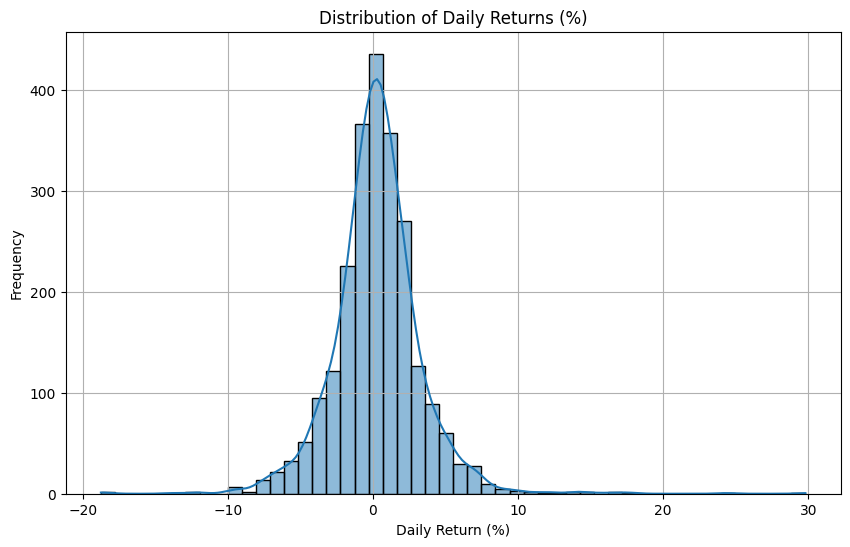

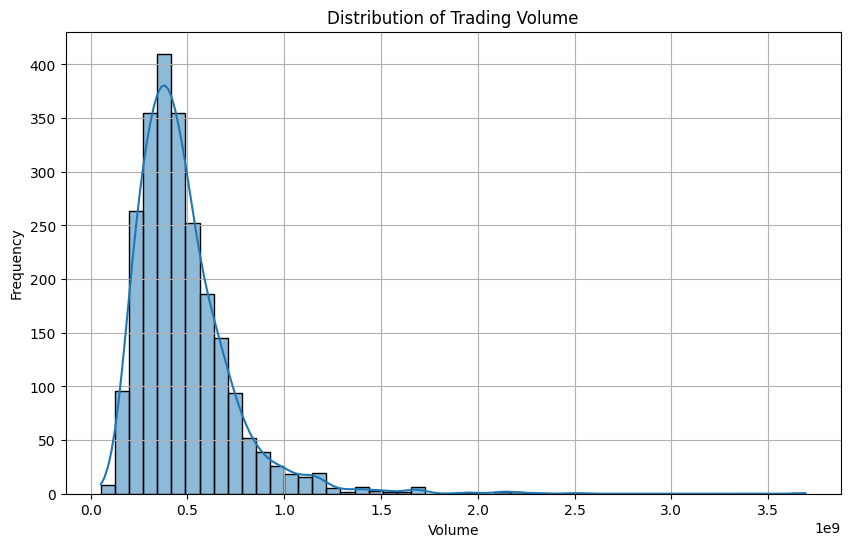

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# การแจกแจงของผลตอบแทนรายวัน
plt.figure(figsize=(10, 6))
sns.histplot(df_stock['Daily_Return'], bins=50, kde=True)
plt.title('Distribution of Daily Returns (%)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# การแจกแจงของปริมาณการซื้อขาย
plt.figure(figsize=(10, 6))
sns.histplot(df_stock['volume'], bins=50, kde=True)
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**bar chart** : ***AdjClose three_days***




**ราคาหุ้นอาจจะลงตอนข่าวออก เฉพาะช่วงเวลาหนึ่ง และไม่สามารถวัดได้จากราคา adjclose รายวัน**


reaction ของข่าวแรง ๆ เช่น CPI :

- ช่วง นาทีแรกหลังประกาศ ลงแรง

- ช่วง 15–60 นาทีแรก เริ่มดีดกลับ

- แต่หลังจากนั้น ราคาอาจดีดกลับจนปิดบวกได้

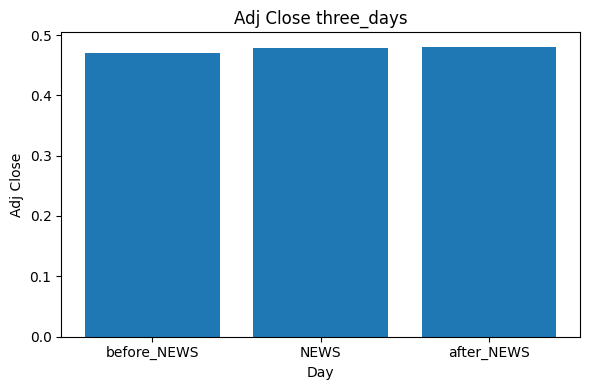

,date,adjclose,event,impact,actual,forecast,previous
9,2015-01-15,0.470496,NaN,NaN,NaN,NaN,NaN
10,2015-01-16,0.479137,CPI y/y; Core CPI m/m; CPI m/m,High Impact Expected,0.8,0.7,1.3
11,2015-01-20,0.480578,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# กำหนด "วันข่าว" ที่ต้องการ (จากตัวอย่างในรูปคือ 2015-01-16)
news_date = pd.to_datetime('2015-01-16')

news_idx_list = df_merged.index[df_merged['date'] == news_date].tolist()
news_idx = news_idx_list[0]

# เลือกแค่ 3 วัน: ก่อนข่าว / ข่าว / หลังข่าว
three_days = df_merged.loc[[news_idx - 1, news_idx, news_idx + 1], ['date', 'adjclose', 'event', 'impact', 'actual', 'forecast', 'previous']]
df_3days = df_merged.loc[[news_idx - 1, news_idx, news_idx + 1]]

# ทำ label ภาษาไทย เผื่ออยากโชว์ใต้กราฟ
labels_th = ['before_NEWS', 'NEWS', 'after_NEWS']

# bar chart
plt.figure(figsize=(6,4))
plt.bar(labels_th, three_days['adjclose'])

plt.xlabel('Day')
plt.ylabel('Adj Close')
plt.title('Adj Close three_days')
plt.tight_layout()
plt.show()

print("")
three_days


In [ ]:
import pandas as pd

df = df_merged.copy()   # สมมติใช้ชื่อ df_merged

# คำนวณผลตอบแทนรายวัน
df['ret_t'] = df['adjclose'].pct_change()
df['ret_t1'] = df['adjclose'].pct_change().shift(-1)  # ผลตอบแทนวันถัดไป

# เลือกเฉพาะแถวที่มี CPI
mask_cpi = df['event'].str.contains('CPI', case=False, na=False)
cpi = df[mask_cpi].copy()

# วัด surprise = actual - forecast
cpi['surprise'] = cpi['actual'] - cpi['forecast']

# กลุ่มที่เงินเฟ้อ "สูงกว่าคาด" (surprise > 0)
cpi_pos = cpi[cpi['surprise'] > 0]

# ดูค่าเฉลี่ยผลตอบแทนวันข่าวกับวันถัดไป
stats = cpi_pos[['ret_t', 'ret_t1']].mean()
print(stats)


ret_t     0.003666
ret_t1    0.001133
dtype: float64


### Bivariate Analysis

**ความสัมพันธ์ระหว่างปริมาณการซื้อขายและผลตอบแทนรายวัน**

กราฟ Scatter Plot (กราฟกระจาย)

สิ่งที่กราฟบอก :

Volume ไม่สูงมาก (ประมาณ 0.2 - 0.8 ) Daily Return ใกล้ศูนย์ (อยู่ในช่วง -5% ถึง +5%) หมายความว่าปกติหุ้น NVIDIA เคลื่อนไหวไม่แรงมากในแต่ละวัน Volume สูงผิดปกติ มาพร้อมกับ Daily Return ที่กระจายออกไปกว้างขึ้นแสดงว่าเวลามีข่าวใหญ่หรือเหตุการณ์สำคัญราคาผันผวนแรง

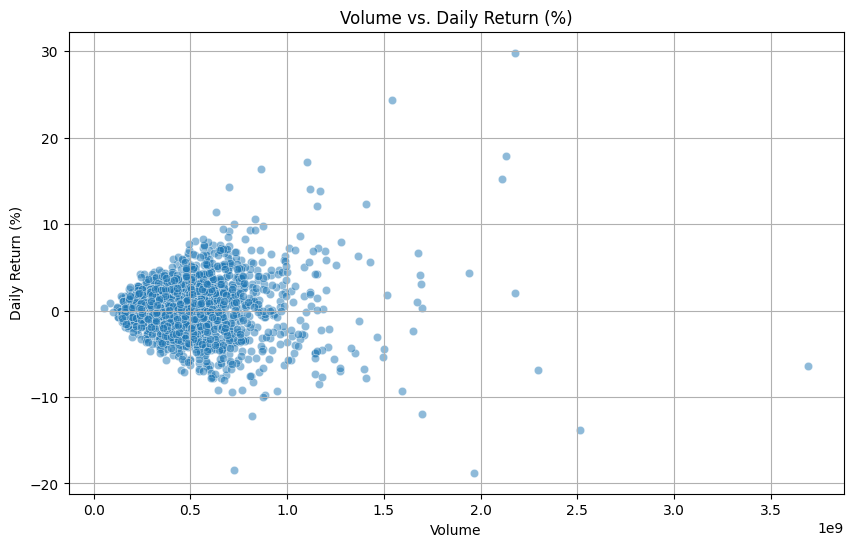

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_stock['volume'], y=df_stock['Daily_Return'], alpha=0.5)
plt.title('Volume vs. Daily Return (%)')
plt.xlabel('Volume')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()

##Multivariate Analysis

**กราฟ แนวโน้มราคาหุ้น NVIDIA ในมุมมองระยะยาวแบบปีต่อปี โดยใช้ MA50 และ MA200**


1.แนวโน้มราคา (Trend)

ถ้าราคาอยู่เหนือ MA50 และ MA200 → ขาขึ้นแข็งแรง

ถ้าราคาอยู่ต่ำกว่า MA200 → เป็นขาลงในภาพใหญ่

2.สัญญาณตัดกันของเส้น MA

Golden Cross : MA50 ตัดขึ้นเหนือ MA200 → เป็นสัญญาณบวก

Death Cross : MA50 ตัดลงต่ำกว่า MA200 → เป็นสัญญาณลบ (หุ้นอาจเริ่มเป็นขาลง)


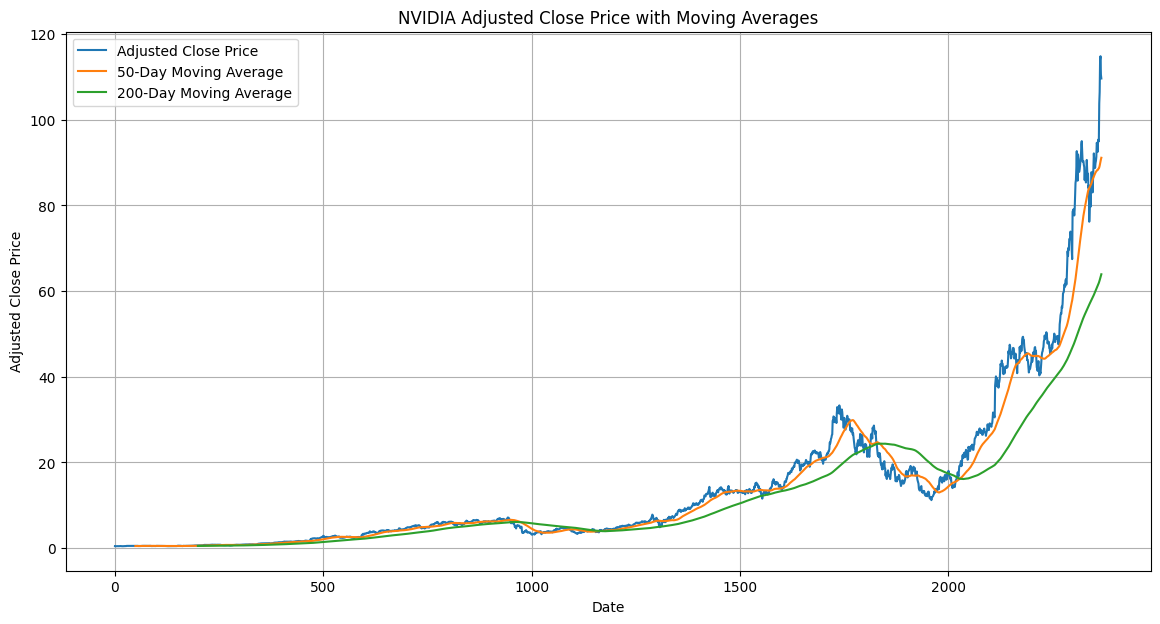

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_stock['adjclose'], label='Adjusted Close Price')
plt.plot(df_stock['MA50'], label='50-Day Moving Average')
plt.plot(df_stock['MA200'], label='200-Day Moving Average')
plt.title('NVIDIA Adjusted Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

**pairplot**

การกระจายตัว

* adjclose และ volume มี เบ้ขวา (right-skewed) ชัด—มีค่าต่ำ ๆ เยอะและมีหางขวายาว (มี outliers ระดับสูง)

*  Daily_Return_pct กระจุกใกล้ 0 ดูคล้ายปกติเล็กน้อยแต่มีหางหนากว่าเล็กน้อย → ส่วนใหญ่ผลตอบแทนรายวันเล็ก ๆ บวกลบรอบศูนย์

ความสัมพันธ์ระหว่างตัวแปร (off-diagonal)

* adjclose × Daily_Return_pct: กลุ่มจุดกระจายเป็นก้อนกลม ๆ → ความสัมพันธ์เชิงเส้นแทบไม่มี (สอดคล้องกับคอร์เรเลชันที่ใกล้ 0)

* volume × Daily_Return_pct: ก็แทบไม่มีความสัมพันธ์เชิงเส้นชัดเจน มี outliers ผลตอบแทนมาก ๆ กับวอลุ่มสูง/ต่ำบางจุด

* adjclose × volume: รูปทรงเหมือน funnel (heteroscedasticity)—กระจายกว้างขึ้นในบางช่วงราคา และโดยรวมความสัมพันธ์เชิงเส้น อ่อนมาก




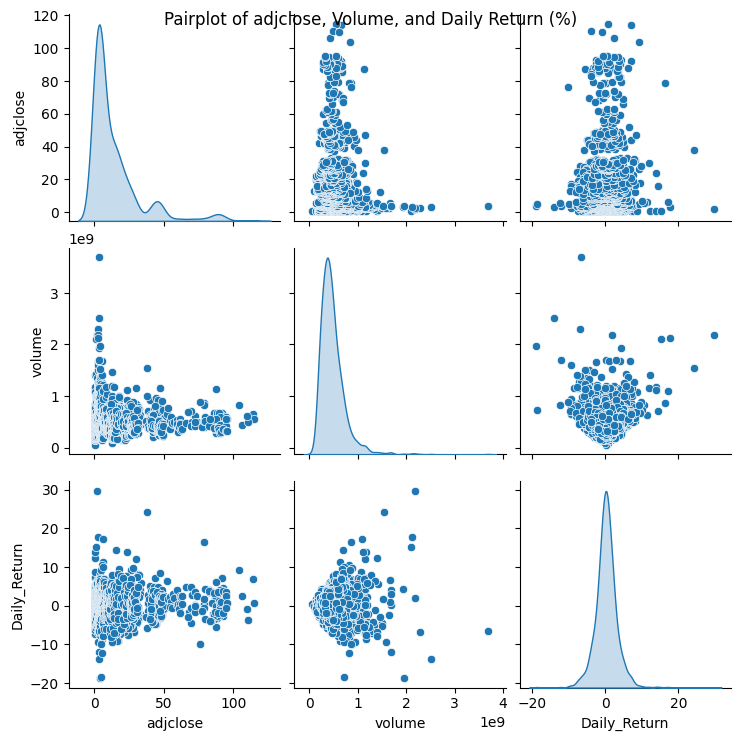

In [ ]:
sns.pairplot(df_stock[['adjclose', 'volume', 'Daily_Return']], diag_kind='kde')
plt.suptitle('Pairplot of adjclose, Volume, and Daily Return (%)')
plt.show()

**Heatmap**

* ราคาแต่ละคอลัมน์ (high/low/open/close/adjclose) แดงเข้มเกือบหมด

* MA50 และ MA200 แดงจัดกับราคาทุกตัว (≈0.96–0.99) และกันเองก็สูง (≈0.97) → เป็นตัวแทนแนวโน้มราคา ระดับข้อมูลค่อนข้างซ้ำซ้อนกับราคาจริง

* volume แทบไม่สัมพันธ์กับราคา/เส้นค่าเฉลี่ย (ค่าใกล้ 0) → ปริมาณซื้อขายในรูป “ระดับรายวัน” ไม่ได้เคลื่อนไปกับระดับราคาอย่างเป็นเส้นตรงชัดเจน

* Daily_Return_pct มีค่าสหสัมพันธ์ต่ำมากและ Volume (ใกล้ 0 ทั้งหมด)เป็นเรื่องปกติ เพราะ ผลตอบแทนรายวัน ไม่ควรขึ้นกับ ระดับราคา โดยตรง

ไม่มีคู่ไหนติดลบแรงไม่ค่อยมีความสัมพันธ์แบบสวนทางชัดเจนในชุดตัวแปรนี้

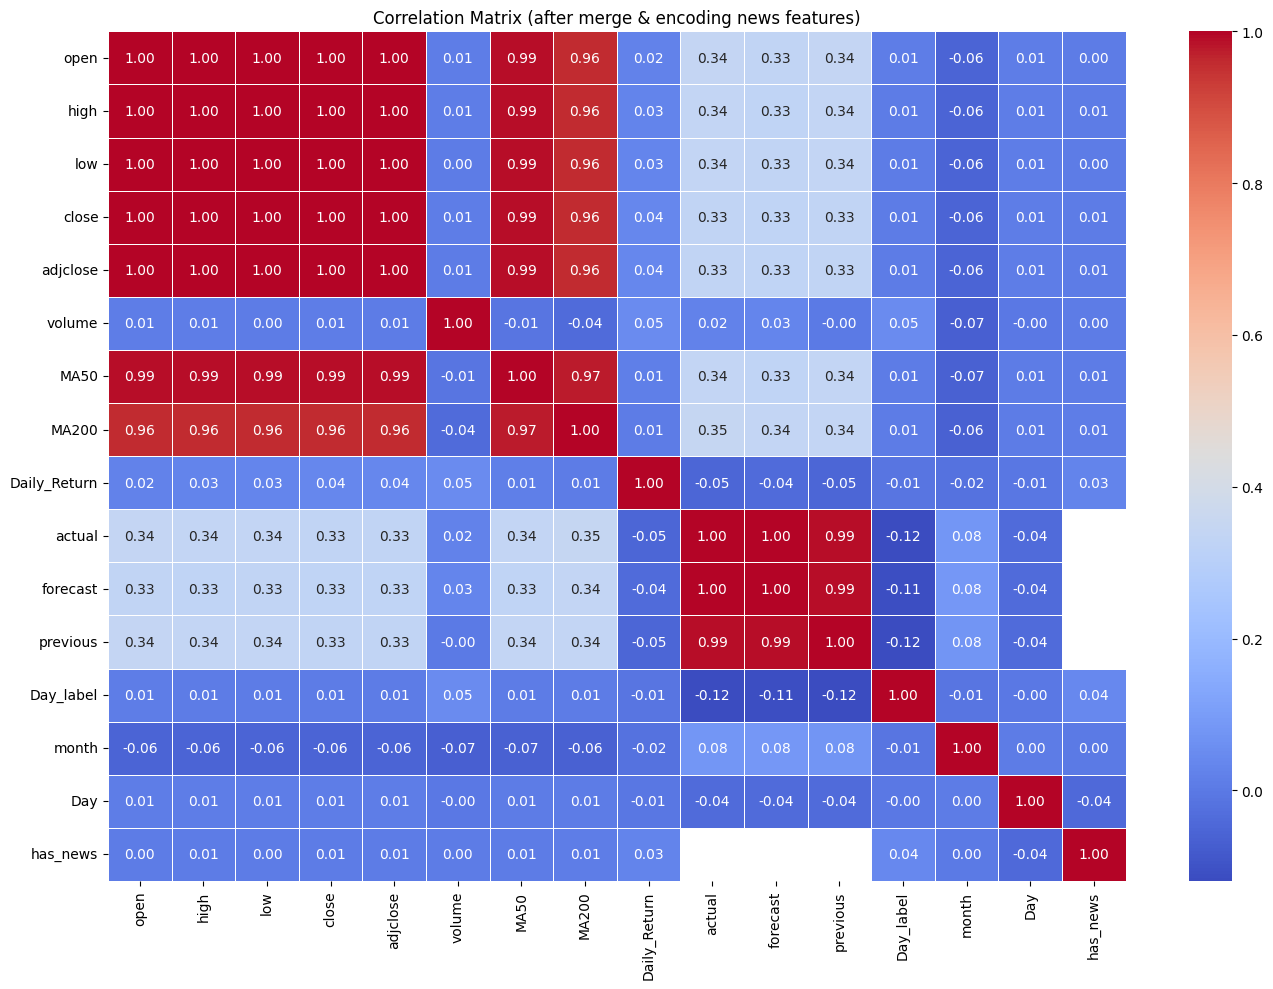

In [ ]:
df = df_merged.copy()

df["has_news"] = df["event"].notna().astype(int) if "event" in df.columns else np.nan

# Calculate the correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5)

plt.title("Correlation Matrix (after merge & encoding news features)")
plt.tight_layout()
plt.show()

## Pattern & Trend Detection

**Line Plot ของ 'adjclose' เทียบกับ 'date'**

กราฟนี้กำลังแสดงการเปลี่ยนแปลงของ ราคาหุ้น NVIDIA (Adjusted Close Price) ในช่วงปี 2015 ถึง 2024

- ราคาหุ้นมีการเติบโตอย่างมาก โดยเฉพาะตั้งแต่ช่วงปี 2020 เป็นต้นมาและยังเติบโตขึ้นเรื่่อยๆ

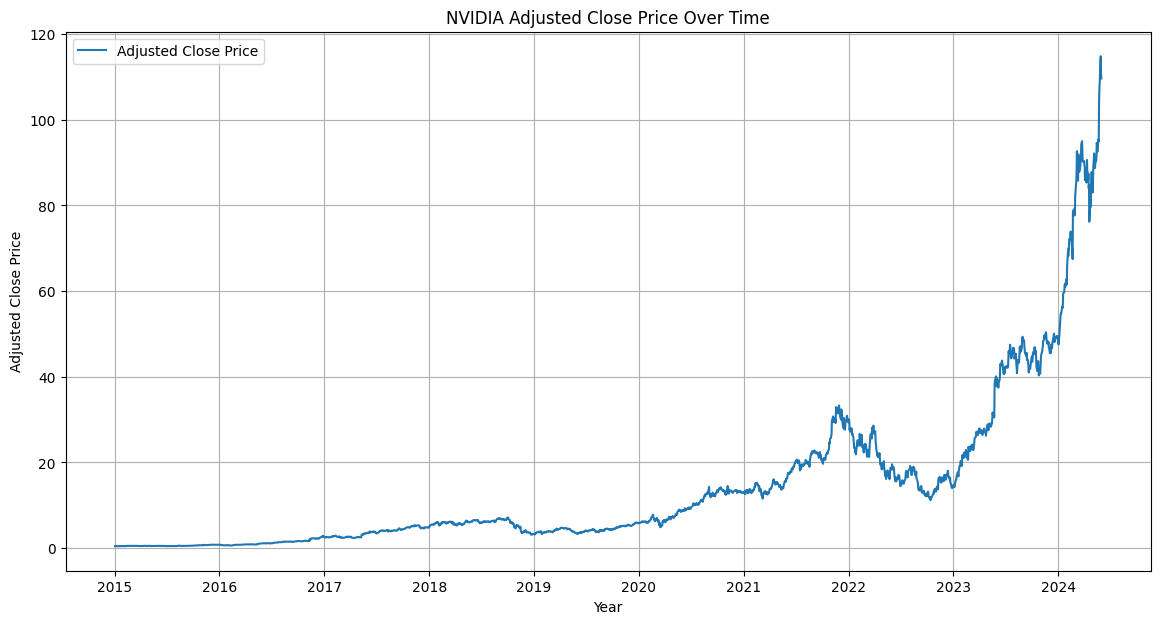

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df_stock['date'], df_stock['adjclose'], label='Adjusted Close Price')
plt.title('NVIDIA Adjusted Close Price Over Time')
plt.xlabel('Year')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)

plt.show()

**กราฟแท่ง ( bar chart ) แสดง ปริมาณการซื้อขายหุ้น NVIDIA รวมต่อปี**



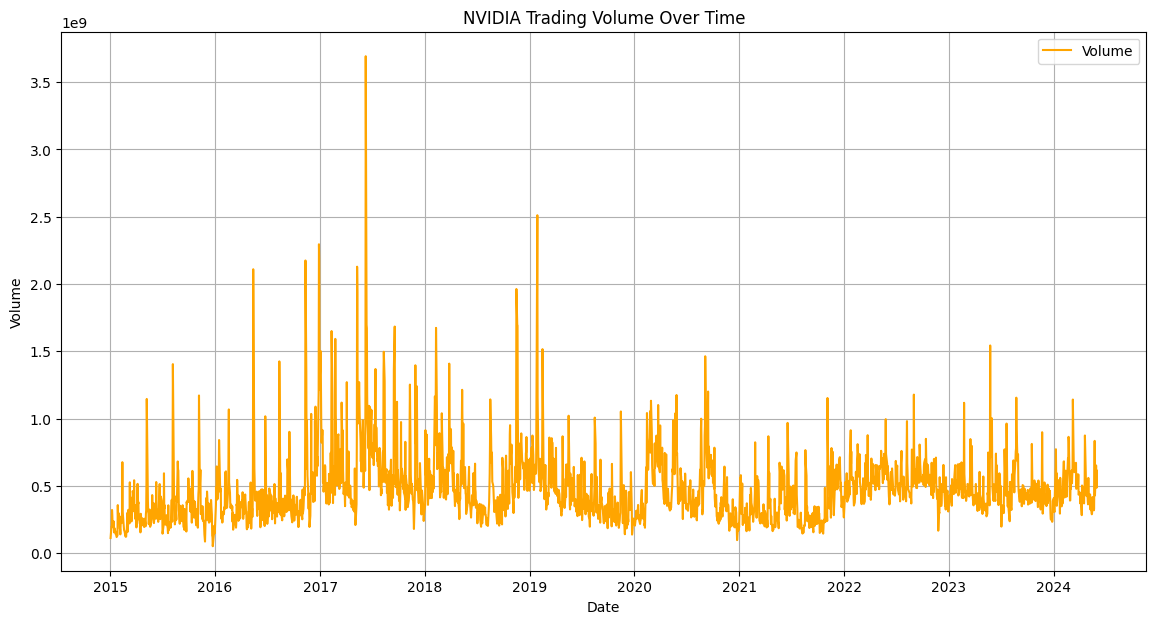

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_stock['date'], df_stock['volume'], label='Volume', color='orange')
plt.title('NVIDIA Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

**กราฟ Time Series Line Chart :  Daily Return (ผลตอบแทนรายวัน) ของหุ้น NVIDIA**

ส่วนใหญ่ค่า Daily Return จะอยู่ใกล้ ๆ 0 แต่ก็มีความผันผวนสูงบางช่วง

!!! จุดที่เส้นพุ่งขึ้นหรือลงแรงผิดปกติ มักตรงกับข่าวใหญ่ เหตุการณ์เศรษฐกิจ หรือผลประกอบการบริษัท

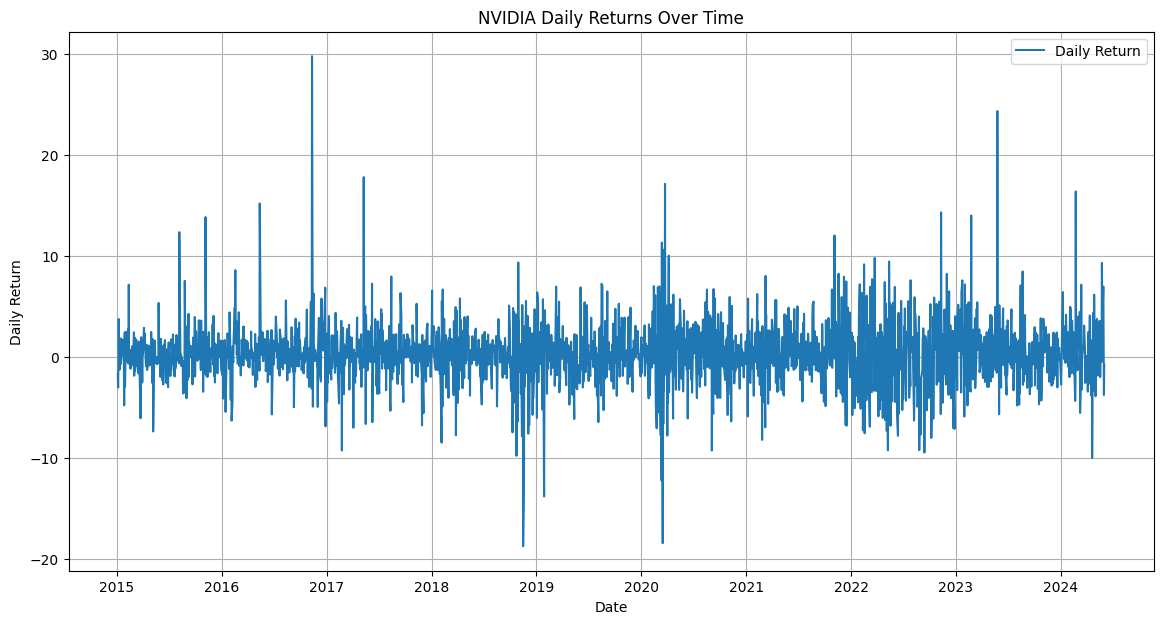

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df_stock['date'], df_stock['Daily_Return'], label='Daily Return')
plt.title('NVIDIA Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True)
plt.show()

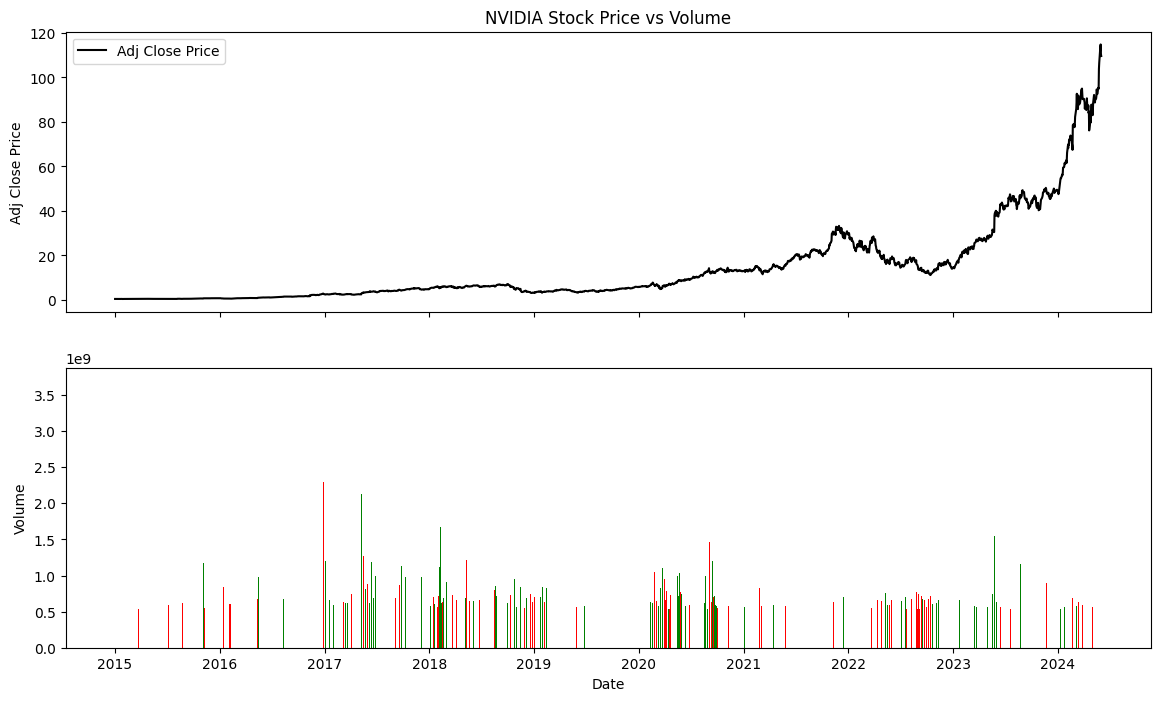

In [ ]:
# คำนวณการเปลี่ยนแปลงของราคาปรับแล้ว
price_change = df_stock["adjclose"].diff()

# กำหนด threshold สำหรับ volume สูง
high_threshold = df_stock["volume"].quantile(0.7)

# สร้าง list ของสีตามเงื่อนไข
colors = []
for i in range(len(df_stock)):
              # ตำแหน่งลำดับแถว
    vol = df_stock["volume"].iloc[i]
    chg = price_change.iloc[i]

    if vol >= high_threshold:
        if chg > 0:
            colors.append("green")
        elif chg < 0:
            colors.append("red")
    else:
        colors.append("white")

# วาดกราฟ
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# กราฟราคา
ax1.plot(df_stock["date"], df_stock["adjclose"], label="Adj Close Price", color="black")
ax1.set_title("NVIDIA Stock Price vs Volume")
ax1.set_ylabel("Adj Close Price")
ax1.legend()

# กราฟ Volume พร้อมสีตามเงื่อนไข
ax2.bar(df_stock["date"], df_stock["volume"], color=colors)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")

plt.show()

In [ ]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2369 entries, 0 to 2368
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          2369 non-null   datetime64[ns]
 1   open          2369 non-null   float64       
 2   high          2369 non-null   float64       
 3   low           2369 non-null   float64       
 4   close         2369 non-null   float64       
 5   adjclose      2369 non-null   float64       
 6   volume        2369 non-null   int64         
 7   MA50          2320 non-null   float64       
 8   MA200         2170 non-null   float64       
 9   Daily_Return  2368 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 185.2 KB


In [ ]:
df_stock.head()

,date,open,high,low,close,adjclose,volume,MA50,MA200,Daily_Return
0,2015-01-02,0.50325,0.50700,0.49525,0.50325,0.483218,113680000,NaN,NaN,NaN
1,2015-01-05,0.50325,0.50475,0.49250,0.49475,0.475056,197952000,NaN,NaN,-1.689029
2,2015-01-06,0.49550,0.49600,0.47925,0.47975,0.460654,197764000,NaN,NaN,-3.031828
3,2015-01-07,0.48325,0.48750,0.47700,0.47850,0.459453,321808000,NaN,NaN,-0.260569
4,2015-01-08,0.48400,0.49950,0.48375,0.49650,0.476737,283780000,NaN,NaN,3.761773


# Feature Engineering




In [ ]:
price_cols = ['open', 'high', 'low', 'close', 'volume', 'adjclose']

# สร้างฟีเจอร์ t-1 แล้วเติม suffix '_t-1'
lag_df = df_merged[price_cols].shift(1).add_suffix('_t-1')

# ทำ open_t = open ของวันปัจจุบัน (optional ตามรูปที่คุณวง)
current_open = df_merged[['open']].rename(columns={'open': 'open_t'})

df_new = pd.concat(
    [
        df_merged[['date', 'Day_label', 'month', 'Day']],  # ข้อมูลวันที่ + label วัน/เดือน (numerical)
        lag_df,                                      # ฟีเจอร์ t-1
        current_open,                                # open_t ของวันนี้
        df_merged[['adjclose']]                      # เป้าหมายของวันนี้
    ],
    axis=1
)

df_new = df_new.dropna().reset_index(drop=True)

print(df_new.tail())

           date  Day_label  month  Day    open_t-1    high_t-1     low_t-1  \
2363 2024-05-24          4      5   24  102.028000  106.320000  101.519997   
2364 2024-05-28          1      5   28  104.448997  106.474998  103.000000   
2365 2024-05-29          2      5   29  110.244003  114.939003  109.883003   
2366 2024-05-30          3      5   30  113.050003  115.491997  110.901001   
2367 2024-05-31          4      5   31  114.650002  115.819000  109.663002   

       close_t-1   volume_t-1  adjclose_t-1      open_t    adjclose  
2363  103.799004  835065000.0    103.790482  104.448997  106.460258  
2364  106.469002  429494000.0    106.460258  110.244003  113.891647  
2365  113.901001  652728000.0    113.891647  113.050003  114.815567  
2366  114.824997  557442000.0    114.815567  114.650002  110.490921  
2367  110.500000  487350000.0    110.490921  112.519997  109.624001  


In [ ]:
df_new.shape

(2368, 12)

# Linear Models for Regression

## Regression with Boston House Prices dataset

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = ['open_t-1', 'high_t-1', 'low_t-1',
                'close_t-1', 'volume_t-1', 'adjclose_t-1',
                'Day_label', 'month', 'Day'] # Updated to use numerical date features

X = df_new[feature_cols]
y = df_new['adjclose']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X.shape)
print(y.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2368, 9)
(2368,)
(1894, 9)
(1894,)
(474, 9)
(474,)


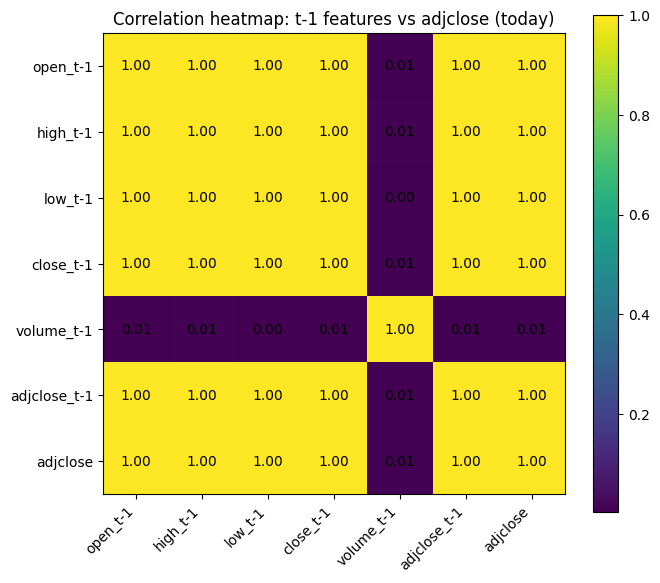

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_cols = ['open_t-1', 'high_t-1', 'low_t-1',
                'close_t-1', 'volume_t-1', 'adjclose_t-1']

cols_for_corr = feature_cols + ['adjclose']
corr = df_new[cols_for_corr].corr()

# วาด heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values)

# ทำให้แกนแสดงชื่อคอลัมน์
ax.set_xticks(np.arange(len(cols_for_corr)))
ax.set_yticks(np.arange(len(cols_for_corr)))
ax.set_xticklabels(cols_for_corr, rotation=45, ha='right')
ax.set_yticklabels(cols_for_corr)

# ใส่ค่าคอร์เรเลชันบน heatmap
for i in range(len(cols_for_corr)):
    for j in range(len(cols_for_corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha='center', va='center')

plt.title('Correlation heatmap: t-1 features vs adjclose (today)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



### LinearRegression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lin = LinearRegression()
lin.fit(X_train, y_train)

# ประเมินความแม่นยำ
y_pred_train = lin.predict(X_train)
y_pred_test  = lin.predict(X_test)

print("\nคะแนนประเมิน")
print(f" Training set score : {lin.score(X_train, y_train):.3f}")
print(f" Test set score     : {lin.score(X_test, y_test):.3f}")
print(f"  R^2 (train)       : {r2_score(y_train, y_pred_train):.3f}")
print(f"  R^2 (test)        : {r2_score(y_test,  y_pred_test):.3f}")
print(f"  MSE (train)       : {mean_squared_error(y_train, y_pred_train):.3f}")
print(f"  MSE (test)        : {mean_squared_error(y_test,  y_pred_test):.3f}")


print("linre.coef_: {}".format(lin.coef_))
print("linre.intercept_: {}".format(lin.intercept_))


คะแนนประเมิน
 Training set score : 0.998
 Test set score     : 0.998
  R^2 (train)       : 0.998
  R^2 (test)        : 0.998
  MSE (train)       : 0.562
  MSE (test)        : 0.486
linre.coef_: [ 8.10625704e-02 -1.72959339e-02 -1.19902408e-01 -1.39354400e+00
 -1.86805774e-11  2.45374537e+00 -2.68014475e-03 -6.24117815e-03
 -2.61605374e-05]
linre.intercept_: 0.06291594757631991


### Ridge Regression + polynomial feature

In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

In [ ]:
pipe = Pipeline([
    ("poly",  PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "poly__degree": [1, 2, 3], # ลองได้หลายค่า
    "ridge__alpha": [1, 3, 10, 30, 100, 300, 1000]
}

grid = GridSearchCV(pipe, param_grid, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model_Ridge = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'poly__degree': 1, 'ridge__alpha': 1}


In [ ]:
# train score
y_train_pred = best_model_Ridge.predict(X_train)
# test score
y_test_pred = best_model_Ridge.predict(X_test)

print(f"R^2 (train): {r2_score(y_train, y_train_pred):.3f}")
print(f"R^2 (test) : {r2_score(y_test,  y_test_pred):.3f}")

print(f"MSE (train): {mean_squared_error(y_train, y_train_pred):.3f}")
print(f"MSE (test) : {mean_squared_error(y_test,  y_test_pred):.3f}")

R^2 (train): 0.998
R^2 (test) : 0.998
MSE (train): 0.575
MSE (test) : 0.503


In [ ]:
# add polynomial feature
poly = PolynomialFeatures(degree=1, include_bias=False) # ปรับ degree ได้
X_train__rd_poly = poly.fit_transform(X_train)
X_test__rd_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly_sc = scaler.fit_transform(X_train__rd_poly)
X_test_poly_sc = scaler.transform(X_test__rd_poly)

print(X_train__rd_poly.shape)
print(X_test__rd_poly.shape)

(1894, 9)
(474, 9)


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly_sc, y_train)

Ridge()

In [ ]:
print(f"R^2 (train): {ridge.score(X_train_poly_sc, y_train):.3f}")
print(f"R^2 (test) : {ridge.score(X_test_poly_sc, y_test):.3f}")

print(f"MSE (train): {mean_squared_error(y_train, ridge.predict(X_train_poly_sc)):.3f}")
print(f"MSE (test) : {mean_squared_error(y_test,  ridge.predict(X_test_poly_sc)):.3f}")

R^2 (train): 0.998
R^2 (test) : 0.998
MSE (train): 0.575
MSE (test) : 0.503


### Lasso Regression + polynomial feature

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
pipe = Pipeline([
    ("poly",  PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("lasso", Lasso(max_iter=10000, random_state=42))
])

param_grid = {
    "poly__degree": [1, 2, 3],                  # ลองหลาย degree ได้
    "lasso__alpha": [1, 3, 10, 30, 100, 300, 1000]
}

grid = GridSearchCV(pipe, param_grid, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model_Lasso = grid.best_estimator_
print("Best params:",
      {"poly__degree": grid.best_params_["poly__degree"],
       "lasso__alpha": float(grid.best_params_["lasso__alpha"])})

Best params: {'poly__degree': 2, 'lasso__alpha': 1.0}


In [ ]:
# train score
y_train_pred_Lasso = best_model_Lasso.predict(X_train)
# test score
y_test_pred_Lasso = best_model_Lasso.predict(X_test)

print(f"R^2 (train): {r2_score(y_train, y_train_pred_Lasso):.3f}")
print(f"R^2 (test) : {r2_score(y_test,  y_test_pred_Lasso):.3f}")

print(f"MSE (train): {mean_squared_error(y_train, y_train_pred_Lasso):.3f}")
print(f"MSE (test) : {mean_squared_error(y_test,  y_test_pred_Lasso):.3f}")

R^2 (train): 0.980
R^2 (test) : 0.942
MSE (train): 1.128
MSE (test) : 36.340


In [ ]:
# add polynomial feature
polyFeat = PolynomialFeatures(degree=1) # ปรับ degree ได้
X_train_ls_poly = polyFeat.fit_transform(X_train)
X_test_ls_poly  = polyFeat.transform(X_test)

scaler = StandardScaler()
X_train_ls_poly_sc = scaler.fit_transform(X_train_ls_poly)
X_test_ls_poly_sc  = scaler.transform(X_test_ls_poly)

print(X_train_ls_poly.shape)
print(X_test_ls_poly.shape)

(1894, 7)
(474, 7)


In [ ]:
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_ls_poly_sc, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.493e+01, tolerance: 1.059e+01
  model = cd_fast.enet_coordinate_descent(


Lasso()

In [ ]:
print(f"R^2 (train): {lasso.score(X_train_ls_poly_sc, y_train):.3f}")
print(f"R^2 (test) : {lasso.score(X_test_ls_poly_sc,  y_test):.3f}")

print(f"MSE (train): {mean_squared_error(y_train, lasso.predict(X_train_ls_poly_sc)):.3f}")
print(f"MSE (test) : {mean_squared_error(y_test,  lasso.predict(X_test_ls_poly_sc)):.3f}")

R^2 (train): 0.980
R^2 (test) : 0.941
MSE (train): 1.133
MSE (test) : 37.450


### Elastic Net + polynomial feature

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
pipe = Pipeline([
    ("poly",  PolynomialFeatures(include_bias=False)),
    ("scale", StandardScaler()),
    ("en",    ElasticNet(max_iter=10000, random_state=42))
])

param_grid = {
    "poly__degree": [1, 2, 3],                    # ลองหลาย degree ได้
    "en__alpha":    [1, 3, 10, 30, 100, 300, 1000],       # 0.001 ... 100
    "en__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(pipe, param_grid, scoring="r2", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model_Elastic = grid.best_estimator_
print("Best params:", {
    "poly__degree": grid.best_params_["poly__degree"],
    "en__alpha":    float(grid.best_params_["en__alpha"]),
    "en__l1_ratio": grid.best_params_["en__l1_ratio"],
})

Best params: {'poly__degree': 1, 'en__alpha': 1.0, 'en__l1_ratio': 0.9}


In [ ]:
# add polynomial feature
polyFeat = PolynomialFeatures(degree=1) # ปรับ degree ได้
X_train_En_poly = polyFeat.fit_transform(X_train)
X_test_En_poly  = polyFeat.transform(X_test)

scaler = StandardScaler()
X_train_En_poly_sc = scaler.fit_transform(X_train_En_poly)
X_test_En_poly_sc  = scaler.transform(X_test_En_poly)

print(X_train_En_poly.shape)
print(X_test_En_poly.shape)

(1894, 10)
(474, 10)


In [ ]:
EN = ElasticNet(alpha=1.0, l1_ratio=0.9)
EN.fit(X_train_En_poly_sc, y_train)

ElasticNet(l1_ratio=0.9)

In [ ]:
print(f"R^2 (train): {EN.score(X_train_En_poly_sc, y_train):.3f}")
print(f"R^2 (test) : {EN.score(X_test_En_poly_sc,  y_test):.3f}")
print(f"MSE (train): {mean_squared_error(y_train, EN.predict(X_train_En_poly_sc)):.3f}")
print(f"MSE (test) : {mean_squared_error(y_test,  EN.predict(X_test_En_poly_sc)):.3f}")

R^2 (train): 0.994
R^2 (test) : 0.995
MSE (train): 2.198
MSE (test) : 1.428


# Predict adjclose

In [ ]:
last = df_merged.iloc[-1]
last_date = pd.to_datetime(last['date'])

future_date = last_date + pd.Timedelta(days=1)
while future_date.weekday() > 4:
    future_date += pd.Timedelta(days=1)

future_day_label = future_date.weekday()

# Redefine feature_cols to ensure it includes all features used during training
feature_cols = ['open_t-1', 'high_t-1', 'low_t-1',
                'close_t-1', 'volume_t-1', 'adjclose_t-1',
                'Day_label', 'month', 'Day']

X_future = pd.DataFrame([{
    'open_t-1':     last['open'],
    'high_t-1':     last['high'],
    'low_t-1':      last['low'],
    'close_t-1':    last['close'],
    'volume_t-1':   last['volume'],
    'adjclose_t-1': last['adjclose'],
    'Day_label':    future_day_label,
    'month':        future_date.month,
    'Day':          future_date.day
}])[feature_cols]

pred_adjclose = best_model_Ridge.predict(X_future)[0]
print(f"Predicted Adjusted Close Price for {future_date.date()}: {pred_adjclose:.3f}")

Predicted Adjusted Close Price for 2024-06-03: 110.477


In [ ]:
y_pred = best_model_Ridge.predict(X_test)

compare_df = pd.DataFrame({
    'adjclose_actual': y_test,
    'adjclose_predicted': y_pred
})
compare_df = compare_df.sort_index()   # เรียงกลับตามลำดับเดิม
print(compare_df.head(10))

    adjclose_actual  adjclose_predicted
18         0.460894            0.470162
25         0.502902            0.482378
29         0.537229            0.529199
43         0.544840            0.533504
44         0.554238            0.533105
48         0.553515            0.532670
49         0.560262            0.541483
51         0.559539            0.533128
56         0.505321            0.489349
67         0.543394            0.529175


### Scatter Plot: ค่าจริง (Actual) vs. ค่าทำนาย (Predicted) พร้อมเส้นถดถอย

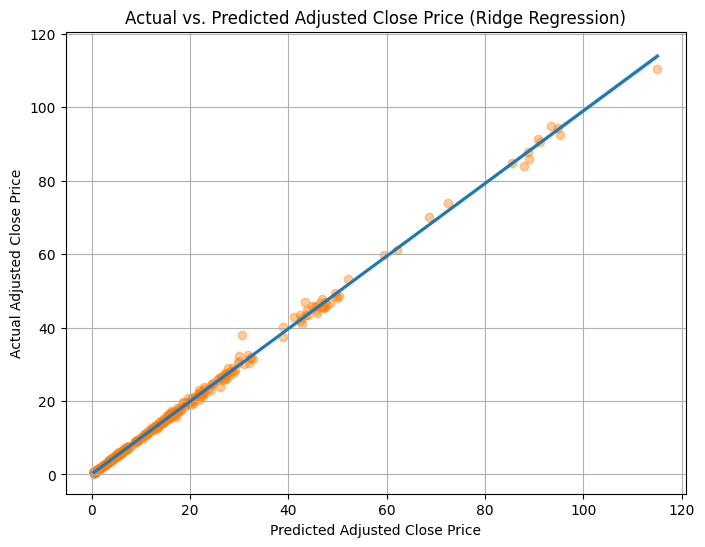

In [ ]:
plt.figure(figsize=(8, 6))

# จุดทุกจุดเป็นส้ม (ค่าพยากรณ์เทียบกับค่าจริง)
sns.regplot(
    x='adjclose_predicted',
    y='adjclose_actual',
    data=compare_df,
    scatter_kws={'alpha': 0.4, 'color': 'tab:orange'},   # จุดส้ม
    line_kws={'color': 'tab:blue'}                       # เส้นฟ้า (เส้นเทรนด์)
)

plt.title('Actual vs. Predicted Adjusted Close Price (Ridge Regression)')
plt.xlabel('Predicted Adjusted Close Price')
plt.ylabel('Actual Adjusted Close Price')
plt.grid(True)
plt.show()


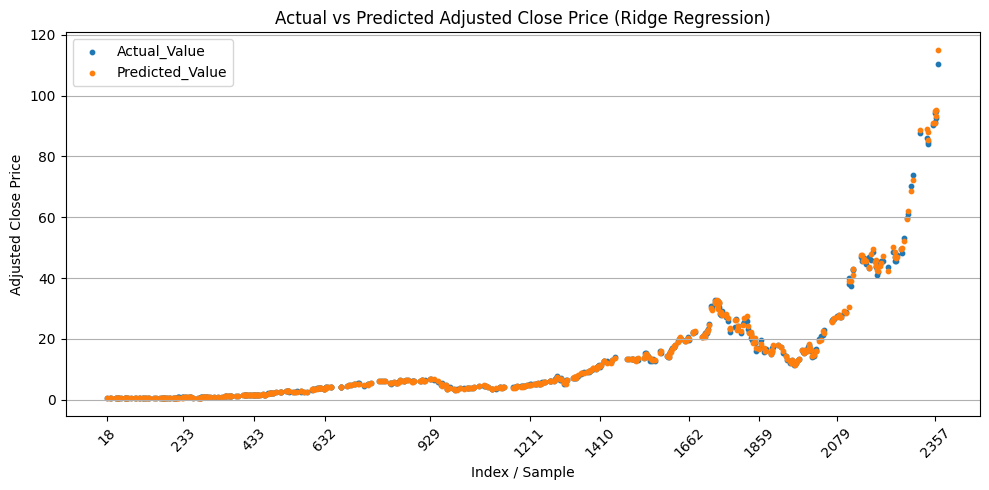

In [ ]:
import matplotlib.pyplot as plt

# compare_df มีคอลัมน์ adjclose_actual, adjclose_predicted และ sort_index() แล้ว
x = compare_df.index.values

plt.figure(figsize=(10, 5))

# actual = น้ำเงิน
plt.scatter(x, compare_df['adjclose_actual'],
            color='tab:blue', s=10, label='Actual_Value')

# predicted = ส้ม
plt.scatter(x, compare_df['adjclose_predicted'],
            color='tab:orange', s=10, label='Predicted_Value')

plt.title('Actual vs Predicted Adjusted Close Price (Ridge Regression)')
plt.xlabel('Index / Sample')
plt.ylabel('Adjusted Close Price')

# ---- เว้นช่วง tick แกน X ----
n_ticks = 10
step = max(1, len(x) // n_ticks)
xticks = x[::step]
plt.xticks(xticks, rotation=45)

plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()

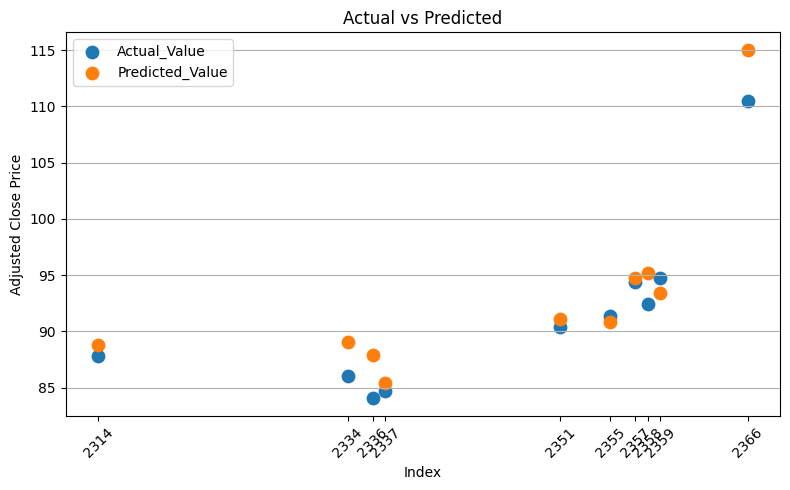

In [ ]:
import matplotlib.pyplot as plt

# เลือก 10 แถวสุดท้าย
sample_df = compare_df.sort_index().tail(10).copy()

plt.figure(figsize=(8, 5))

plt.scatter(sample_df.index, sample_df['adjclose_actual'],
            color='tab:blue', s=80, label='Actual_Value')

plt.scatter(sample_df.index, sample_df['adjclose_predicted'],
            color='tab:orange', s=80, label='Predicted_Value')

plt.title('Actual vs Predicted')
plt.xlabel('Index')
plt.ylabel('Adjusted Close Price')

plt.xticks(sample_df.index, rotation=45)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
print("ตารางเปรียบเทียบค่าจริง (Actual Value) และค่าที่ทำนาย (Predicted Value):")
display(compare_df)

ตารางเปรียบเทียบค่าจริง (Actual Value) และค่าที่ทำนาย (Predicted Value):


,adjclose_actual,adjclose_predicted
18,0.460894,0.470162
25,0.502902,0.482378
29,0.537229,0.529199
43,0.544840,0.533504
44,0.554238,0.533105
...,...,...
2355,91.348495,90.809118
2357,94.351250,94.770267
2358,92.471397,95.170403
2359,94.772217,93.373028


# สรุปผล:
ผลการประเมินประสิทธิภาพของโมเดล Ridge Regression แสดงให้เห็นว่าโมเดลสามารถฟิตกับข้อมูลได้อย่างยอดเยี่ยม ค่า R-squared เท่ากับ 0.998 ทั้งในชุดฝึกและชุดทดสอบ ซึ่งหมายความว่าโมเดลสามารถอธิบายความแปรปรวนของตัวแปรเป้าหมายได้ประมาณ 99.8% ค่า Mean Squared Error (MSE) อยู่ในระดับต่ำ โดยชุดฝึกมีค่า 0.575 และชุดทดสอบมีค่า 0.503 ยิ่งสนับสนุนว่าโมเดลมีความแม่นยำสูง

กราฟ scatter plot (ที่สร้างไว้ก่อนหน้า) แสดงให้เห็นถึงความใกล้เคียงระหว่างค่าจริงและค่าที่พยากรณ์ โดยมีเส้นถดถอยที่บ่งบอกถึงความสัมพันธ์เชิงเส้นอย่างชัดเจน เช่นเดียวกับกราฟเส้น (line plot) ที่แสดงให้เห็นว่าโมเดลสามารถจับแนวโน้มและความผันผวนของราคาปิดปรับด้วยปัจจัยต่าง ๆ ได้เป็นอย่างดี

## ประเด็นสำคัญจากการวิเคราะห์ข้อมูล

โมเดล Ridge Regression ที่ดีที่สุดทำได้ค่า R-squared (R²) = 0.998 ทั้งชุดฝึกและทดสอบ แสดงถึงความสามารถในการอธิบายความแปรปรวนของข้อมูลได้สูงมาก

ค่า MSE ของชุดฝึกคือ 0.575 และชุดทดสอบคือ 0.503 ซึ่งต่ำมาก หมายถึงโมเดลมีข้อผิดพลาดในการพยากรณ์น้อย

กราฟ scatter plot ของค่าจริงเทียบกับค่าพยากรณ์ (สร้างก่อนหน้า) แสดงความสัมพันธ์เชิงเส้นที่แข็งแรงและการจัดเรียงที่ดี แสดงว่าโมเดลฟิตข้อมูลได้ดี

กราฟเส้นของค่าจริงเทียบกับค่าพยากรณ์ตามเวลา (สร้างก่อนหน้า) แสดงว่าโมเดลสามารถจับแนวโน้มและความผันผวนของราคาปิดที่ปรับปรุงแล้วได้อย่างถูกต้อง

## ข้อมูลเชิงลึกและขั้นตอนถัดไป

โมเดล Ridge Regression แสดงประสิทธิภาพที่ยอดเยี่ยมด้วยค่า R-squared สูงและ MSE ต่ำในทั้งสองชุดข้อมูล ซึ่งบ่งชี้ถึงความสามารถในการทั่วไป (generalization) ที่ดีมาก

ด้วยประสิทธิภาพระดับนี้ เหมาะสำหรับนำไปใช้ในระบบพยากรณ์จริง และควรทดสอบเพิ่มเติมกับข้อมูลใหม่ที่ไม่เคยเห็นมาก่อนเพื่อประเมินความแม่นยำในสภาพแวดล้อมจริง

# Insight จาก EDA

Insight จากการวิเคราะห์ข้อมูล nvidia stock 2015 to 2024

 สรุปได้ดังนี้ :

**1. ภาพรวมข้อมูล (Data Overview)**

* แถว : 2369

* คอลัมน์ : 10

* date :                         datetime64[ns]
* open :                         float64       
* high :                         float64       
* low :                          float64       
* close :                        float64       
* adjclose :                     float64       
* volume :                       int64         
* Daily_Return :                 float64       
* Daily_Return_pct :             float64                            
* MA50 :                         float64       
* MA200 :                        float64
* ไม่มี Missing values และ Duplicates

**2.  การกระจายของข้อมูล (Distribution)**
* open: Q1 = 3.00, Q3 = 17.92, IQR = 14.92, low = -19.38, high = 40.29
* high: Q1 = 3.05, Q3 = 18.24, IQR = 15.20, low = -19.75, high = 41.04
* low: Q1 = 2.95, Q3 = 17.63, IQR = 14.69, low = -19.08, high = 39.66
* close: Q1 = 3.03, Q3 = 17.98, IQR = 14.95, low = -19.40, high = 40.41
* adjclose: Q1 = 2.99, Q3 = 17.96, IQR = 14.97, low = -19.47, high = 40.42
* ตรวจสอบ Outliers แล้วพบค่า Outliers แต่ไม่ใช่ค่าผิดพลาด
* ค่า Volume มีการเบ้ขวาและ Daily Return มี outlier เล็กน้อยเพราะมีค่าทีผันผวนมากๆ


**3. ความแตกต่างระหว่างกลุ่ม (Group Differences)**

Categorical vs Numerical
ความสัมพันธ์ : เราอาจใช้ color
(แดง/เขียว) เทียบกับ Volume ถ้าเขียวแรงซื้อเยอะในวันนั้นและถ้าแดงแรงขายเยอะในวันนั้น

**4.  ความสัมพันธ์ระหว่างตัวแปร**
(Relationships)

Scatter Plot (กราฟกระจาย)

สิ่งที่กราฟบอก :

* Volume ไม่สูงมาก (ประมาณ 0.2 - 0.8 ) Daily Return ใกล้ศูนย์ (อยู่ในช่วง -5% ถึง +5%) หมายความว่าปกติหุ้น NVIDIA เคลื่อนไหวไม่แรงมากในแต่ละวัน Volume สูงผิดปกติ มาพร้อมกับ Daily Return ที่กระจายออกไปกว้างขึ้นแสดงว่าเวลามีข่าวใหญ่หรือเหตุการณ์สำคัญราคาผันผวนแรง

Correlation matrix

สิ่งที่กราฟบอก :

* กลุ่มราคาหุ้น (open, high, low, close, adjclose)
มีค่าสหสัมพันธ์เกือบ 1.0 กันหมด → เพราะทั้งหมดเป็นราคาที่เคลื่อนไหวในทิศทางเดียวกัน

* ค่าเฉลี่ยเคลื่อนที่ (MA50, MA200)
มีความสัมพันธ์สูงกับราคาต่างๆ (0.96 - 0.99) → เพราะค่า MA มาจากราคาปิดสะสม

* volume (ปริมาณการซื้อขาย)
แทบไม่มีความสัมพันธ์กับราคา (ค่าประมาณ 0.01–0.04)
แสดงว่า ปริมาณการซื้อขายไม่ได้มีความสัมพันธ์เชิงเส้นตรงกับราคา

* Daily_Return_pct (ผลตอบแทนรายวัน)
มีความสัมพันธ์ใกล้ 0 กับราคาทั้งหมด (≈0.02 - 0.04)
หมายความว่า ระดับราคาหุ้นไม่ได้บอกผลตอบแทนรายวันโดยตรง
เพราะผลตอบแทนรายวันขึ้นกับการเปลี่ยนแปลงของราคา


**5. Pattern และแนวโน้ม**
(Pattern & Trends)

* Line Plot ของ 'adjclose' เทียบกับ 'date' : adjclose หุ้นพุ่งสูงขึ้นอย่างต่อเนื่อง

* กราฟแท่ง ( bar chart ) แสดง ปริมาณการซื้อขายหุ้น NVIDIA รวมต่อปี : มีการซื้อหุ้นกันน้อยลง

* Daily Return (ผลตอบแทนรายวัน) ของหุ้น NVIDIA : มีการผันผวนสูงจาก Volume และ ข่าวใหญ่ๆ

**6. สรุปโดยรวม**

* insight นี่ไม่การันตีว่า Volume มีผลต่อการ adjclose หรือว่า Daily Return เพราะข่าวใหญ่ๆมีผลต่อราคาของหุ้น
แต่ MA50 และ MA200 สามารถช่วยในการติดใจเข้าซื้อได้เพราะไปทางเดียวกันกับราคาของหุ้นส่วนถ้าอยากขายทำกำไรจุดไหนแล้วแต่ความพอใจของนักลงทุน
